# Sri Lanka Skim Coat Dataset Analysis (5000 samples)

"""
EDA, preprocessing, model comparison, and test scaffold for the skim coat dataset.
All operations are in-memory and will not alter the original CSV file.
"""

In [1]:
# 1) Environment & versions
import sys
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn may not be installed; attempt to import and install if missing
try:
    import seaborn as sns
except ModuleNotFoundError:
    print("seaborn not found. Attempting to install via pip...")
    try:
        get_ipython().run_line_magic('pip', 'install seaborn')
        import seaborn as sns
    except Exception as e:
        print("Automatic install failed:", e)
        print("Please install seaborn in your environment (pip install seaborn) and re-run this cell.")

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

%matplotlib inline

Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
scikit-learn: 1.6.1


In [2]:
# 2) Load dataset (read-only)
from pathlib import Path
DATA_PATH = Path('sri_lanka_skim_coat_dataset_5000.csv')
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1000, 4)


,WallSize_sqft,PricePerSqft_LKR,Location,Brand
0,419,742,Indoor,ASIANPAINT Skim Coat
1,587,855,Outdoor,INSEE Skim cement Coat
2,344,835,Outdoor,Tokyo plaster master
3,564,600,Indoor,NIPPON skim coat
4,728,950,Outdoor,Tokyo plaster master


In [3]:
# 3) Inspect dataset structure
print('\nColumns:')
print(df.columns.tolist())

print('\nInfo:')
df.info()

print('\nDtypes:')
print(df.dtypes)


Columns:
['WallSize_sqft', 'PricePerSqft_LKR', 'Location', 'Brand']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   WallSize_sqft     1000 non-null   int64 
 1   PricePerSqft_LKR  1000 non-null   int64 
 2   Location          1000 non-null   object
 3   Brand             1000 non-null   object
dtypes: int64(2), object(2)
memory usage: 31.4+ KB

Dtypes:
WallSize_sqft        int64
PricePerSqft_LKR     int64
Location            object
Brand               object
dtype: object


In [4]:
# 4) Basic in-memory cleaning & missing values
# Strip whitespace from object columns
text_cols = df.select_dtypes(include='object').columns.tolist()
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

print('\nMissing values per column:')
print(df.isna().sum())

# We will use SimpleImputer in the pipeline for formal handling (no changes to CSV)



Missing values per column:
WallSize_sqft       0
PricePerSqft_LKR    0
Location            0
Brand               0
dtype: int64


Numeric columns: ['WallSize_sqft', 'PricePerSqft_LKR']
Categorical columns: ['Location', 'Brand']


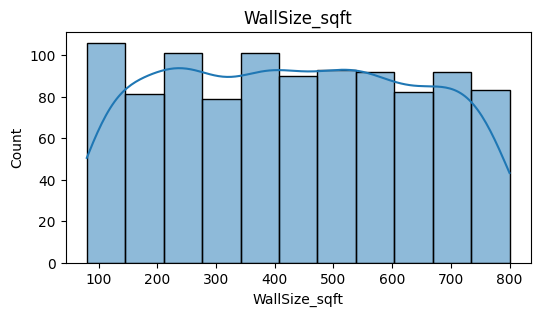

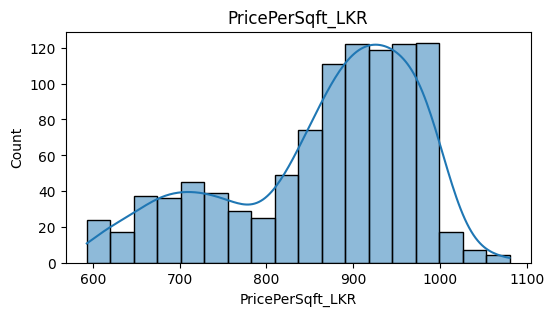


Value counts for Location
Location
Indoor     515
Outdoor    485
Name: count, dtype: int64

Value counts for Brand
Brand
Tokyo plaster master      259
INSEE Skim cement Coat    226
NIPPON skim coat           85
INSEE Skim Coat            79
SF Skim Coat               73
Multilac Skim Coat         73
ASIANPAINT Skim Coat       72
NIPPOFLEX skim coat        69
Swisstek Skim Coat         64
Name: count, dtype: int64


In [5]:
# 5) Exploratory data analysis (examples)
num_cols = df.select_dtypes(include=['int','float']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

for c in num_cols[:4]:
    plt.figure(figsize=(6,3))
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(c)
    plt.show()

for c in cat_cols[:4]:
    print('\nValue counts for', c)
    print(df[c].value_counts().head(20))

In [6]:
# 6) Define features (X) and target (y) and infer problem type
if 'Brand' in df.columns:
    target = 'Brand'
elif 'SkimCoatBrand' in df.columns:
    target = 'SkimCoatBrand'
elif 'PricePerSqft_LKR' in df.columns:
    target = 'PricePerSqft_LKR'
else:
    candidate = None
    for c in df.columns:
        if df[c].nunique() <= 20 and df[c].dtype == 'object':
            candidate = c
            break
    if candidate:
        target = candidate
    else:
        num_cols = df.select_dtypes(include=['number']).columns
        target = num_cols[-1] if len(num_cols)>0 else df.columns[-1]

print('Selected target:', target)

y = df[target]
X = df.drop(columns=[target])

is_classification = (y.dtype == 'object') or (y.nunique() < 50 and y.dtype != 'float')
print('Problem type inferred:', 'classification' if is_classification else 'regression')
print('Feature shape:', X.shape)

Selected target: Brand
Problem type inferred: classification
Feature shape: (1000, 3)


In [7]:
# 7) Train / test split
from sklearn.model_selection import train_test_split

if is_classification:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (800, 3) Test: (200, 3)


In [8]:
# 8) Preprocessing pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = X_train.select_dtypes(include=['int','float']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')),('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocess = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', cat_transformer, categorical_features)])

print('Numeric:', numeric_features)
print('Categorical:', categorical_features)


Numeric: ['WallSize_sqft', 'PricePerSqft_LKR']
Categorical: ['Location']


In [9]:
# 9) Model candidates (conditional)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.svm import LinearSVC

if is_classification:
    models = {
        'Logistic Regression': LogisticRegression(max_iter=3000),
        'Linear SVM': LinearSVC(max_iter=3000),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': HistGradientBoostingClassifier(random_state=42)
    }
else:
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': HistGradientBoostingRegressor(random_state=42)
    }

models

{'Logistic Regression': LogisticRegression(max_iter=3000),
 'Linear SVM': LinearSVC(max_iter=3000),
 'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
 'Gradient Boosting': HistGradientBoostingClassifier(random_state=42)}

In [10]:
# 10) Cross-validation & metric selection
from sklearn.model_selection import cross_validate
import numpy as np

if is_classification:
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'f1_macro']
else:
    from sklearn.model_selection import KFold
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['neg_root_mean_squared_error', 'r2']

results = []
from sklearn.pipeline import Pipeline
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    entry = {'Model': name}
    if is_classification:
        entry['CV Accuracy (Mean)'] = scores['test_accuracy'].mean()
        entry['CV Macro F1 (Mean)'] = scores['test_f1_macro'].mean()
    else:
        entry['CV RMSE (Mean)'] = -scores['test_neg_root_mean_squared_error'].mean()
        entry['CV R2 (Mean)'] = scores['test_r2'].mean()
    results.append(entry)

results_df = pd.DataFrame(results)
results_df

,Model,CV Accuracy (Mean),CV Macro F1 (Mean)
0,Logistic Regression,0.38875,0.252767
1,Linear SVM,0.39125,0.225295
2,Random Forest,0.36500,0.303622
3,Gradient Boosting,0.35625,0.306515


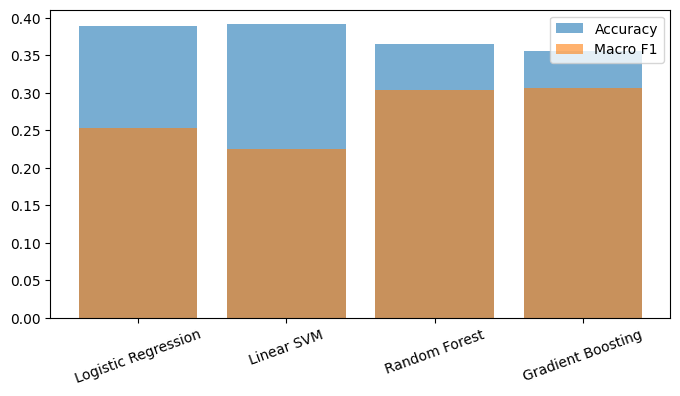

In [11]:
# 11) Visualize CV results
import matplotlib.pyplot as plt

if is_classification:
    plt.figure(figsize=(8,4))
    plt.bar(results_df['Model'], results_df['CV Accuracy (Mean)'], alpha=0.6, label='Accuracy')
    plt.bar(results_df['Model'], results_df['CV Macro F1 (Mean)'], alpha=0.6, label='Macro F1')
    plt.xticks(rotation=20)
    plt.legend()
    plt.show()
else:
    plt.figure(figsize=(8,4))
    plt.bar(results_df['Model'], results_df['CV RMSE (Mean)'])
    plt.xticks(rotation=20)
    plt.ylabel('RMSE')
    plt.show()


In [12]:
# 12) Train best model on full training set and save pipeline
from joblib import dump
from pathlib import Path
from sklearn.pipeline import Pipeline

if is_classification:
    best_name = results_df.sort_values('CV Macro F1 (Mean)', ascending=False).iloc[0]['Model']
else:
    best_name = results_df.sort_values('CV RMSE (Mean)').iloc[0]['Model']

print('Selected model:', best_name)

best_model = models[best_name]
best_pipeline = Pipeline(steps=[('preprocess', preprocess), ('model', best_model)])
best_pipeline.fit(X_train, y_train)

Path('models').mkdir(parents=True, exist_ok=True)
model_path = Path('models') / f'sri_lanka_skimcoat_pipeline_{best_name.replace(" ","_")}.joblib'
dump(best_pipeline, model_path)
print('Saved pipeline to', model_path)


Selected model: Gradient Boosting
Saved pipeline to models\sri_lanka_skimcoat_pipeline_Gradient_Boosting.joblib


In [13]:
# 13) Final test evaluation
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error, r2_score, mean_absolute_error

y_pred = best_pipeline.predict(X_test)

if is_classification:
    print('Test Accuracy:', accuracy_score(y_test, y_pred))
    print('Test Macro F1:', f1_score(y_test, y_pred, average='macro'))
    print('\nClassification Report:\n', classification_report(y_test, y_pred))
else:
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    print('Test RMSE:', rmse)
    print('Test MAE:', mean_absolute_error(y_test, y_pred))
    print('Test R2:', r2_score(y_test, y_pred))

Test Accuracy: 0.33
Test Macro F1: 0.23251333560322326

Classification Report:
                         precision    recall  f1-score   support

  ASIANPAINT Skim Coat       0.17      0.21      0.19        14
       INSEE Skim Coat       0.24      0.25      0.24        16
INSEE Skim cement Coat       0.45      0.44      0.45        45
    Multilac Skim Coat       0.18      0.20      0.19        15
   NIPPOFLEX skim coat       0.00      0.00      0.00        14
      NIPPON skim coat       0.27      0.24      0.25        17
          SF Skim Coat       0.21      0.29      0.24        14
    Swisstek Skim Coat       0.00      0.00      0.00        13
  Tokyo plaster master       0.53      0.54      0.53        52

              accuracy                           0.33       200
             macro avg       0.23      0.24      0.23       200
          weighted avg       0.32      0.33      0.32       200



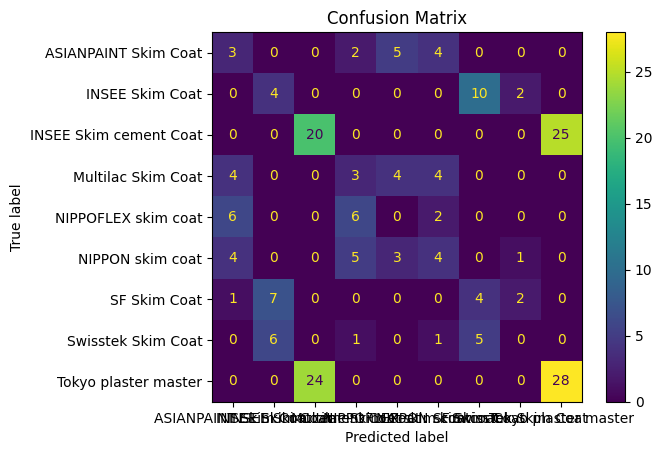

In [14]:
# 14) Confusion matrix or residual plot
import matplotlib.pyplot as plt

if is_classification:
    from sklearn.metrics import ConfusionMatrixDisplay
    labels = sorted(y_test.unique()) if hasattr(y_test, 'unique') else None
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=labels)
    plt.title('Confusion Matrix')
    plt.show()
else:
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs Actual')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.6)
    plt.show()

    plt.figure()
    plt.hist((y_test - y_pred), bins=30)
    plt.title('Residuals')
    plt.show()

In [15]:
# 15) Inference helper
import pandas as pd

def predict_from_dict(pipeline, input_dict):
    row = pd.DataFrame([input_dict])
    missing_cols = [c for c in X.columns if c not in row.columns]
    for c in missing_cols:
        row[c] = None
    row = row[X.columns]
    return pipeline.predict(row)

sample = {c: X.iloc[0][c] if c in X.columns else None for c in (X.columns[:8])}
print('Sample prediction:', predict_from_dict(best_pipeline, sample))

Sample prediction: ['ASIANPAINT Skim Coat']


In [16]:
# 16) Save predictions to a new CSV (NO edits to original data)
preds = pd.DataFrame({'index': X_test.index, 'y_true': y_test, 'y_pred': y_pred})
preds.to_csv('sri_lanka_skim_coat_dataset_5000_predictions.csv', index=False)
print('Saved predictions to sri_lanka_skim_coat_dataset_5000_predictions.csv')

Saved predictions to sri_lanka_skim_coat_dataset_5000_predictions.csv


In [17]:
# 17) Unit test scaffold (writes a pytest test file)
from pathlib import Path
Path('tests').mkdir(exist_ok=True)

test_file = Path('tests/test_skimcoat_pipeline.py')

test_file.write_text('''import pandas as pd
from joblib import load

pipeline = load('models/sri_lanka_skimcoat_pipeline_.joblib')

def test_pipeline_predict_shape():
    assert hasattr(pipeline, 'predict')
''')
print('Wrote', test_file)

Wrote tests\test_skimcoat_pipeline.py


# 18) Notes & next steps
"""
- Verify selected target and adjust feature selection / sample inputs
- Add domain-specific feature engineering for skim coat (surface type, moisture)
- Consider class balancing or regression transformations if needed
- Version models in models/v1/ when ready
"""